In [ ]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Step 2: Load Dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv(url, names=columns)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully!
Shape: (768, 9)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
# Step 3: Explore Dataset
print("Total Rows & Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nTarget Value Counts:")
print(df['Outcome'].value_counts())

print("\nBasic Statistics:")
print(df.describe())

Total Rows & Columns: (768, 9)

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Target Value Counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Basic Statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction        

In [ ]:
# Step 4: Features & Target Variable
X = df.drop('Outcome', axis=1)  # Features (input)
y = df['Outcome']               # Target (output)

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nFeature columns used:")
print(X.columns.tolist())

print("\nTarget variable:")
print("0 = No Diabetes, 1 = Has Diabetes")

Features (X) shape: (768, 8)
Target (y) shape: (768,)

Feature columns used:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target variable:
0 = No Diabetes, 1 = Has Diabetes


In [ ]:
# Step 5: Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Data split successfully!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Data split successfully!
Training samples: 614
Testing samples: 154


In [ ]:
# Step 6: Train Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Algorithm used: Logistic Regression")

Model trained successfully!
Algorithm used: Logistic Regression


In [ ]:
# Step 7: Make Predictions
y_pred = model.predict(X_test)

print("Predictions done!")
print("\nFirst 10 Predictions:", y_pred[:10])
print("First 10 Actual:     ", list(y_test[:10]))

Predictions done!

First 10 Predictions: [0 0 0 0 0 0 0 1 1 1]
First 10 Actual:      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
# Step 8: Check Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("=== MODEL RESULTS ===")
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nDetailed Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Diabetes', 'Diabetes']))

=== MODEL RESULTS ===
Accuracy: 74.68%

Detailed Report:
              precision    recall  f1-score   support

 No Diabetes       0.81      0.79      0.80        99
    Diabetes       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



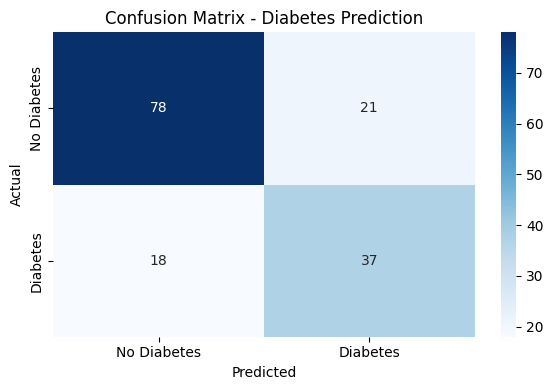

Done! Take screenshot of this graph!


In [ ]:
# Step 9: Confusion Matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Diabetes Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("Done! Take screenshot of this graph!")